# Fine-label mapping: hepatocyte **zonation**

Liver hepatocytes sit on a **portal → central** metabolic gradient. The census-wide
reference shipped with `actinn-jax` includes the three zonation types as *fine* Cell-
Ontology labels — `periportal` (CL:0019026), `midzonal` (CL:0019028) and `centrilobular`
(CL:0019029) region hepatocyte — so we can map a liver dataset straight onto the zonation
axis, on CPU.

Query: a human liver atlas pulled from CELLxGENE with zonation ground truth (see
`benchmark/explore/fetch_liver_query.py` in the companion repo). Point `QUERY` at your own
liver `.h5ad` to reuse this.

## 1. Load reference + liver query, annotate

In [7]:
from collections import Counter

In [2]:
import time, numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt
import actinn_jax as aj

QUERY = '/Users/iandriver/Downloads/Training_data/GSE185477_human_liver_all_good.h5ad'   # <- your liver .h5ad here
model = aj.bundled_reference('broad_human_v1')
adata = sc.read_h5ad(QUERY)
# Gene IDs are matched to the reference automatically: if var_names are symbols
# but the reference uses Ensembl IDs, actinn-jax falls back to a matching .var
# column (e.g. 'Ensembl_id') on its own -- no manual remapping needed here.
adata.obs['cell_type'] = adata.obs['Manual_Annotation']
t = time.perf_counter()
adata = aj.annotate(adata, model,min_prob=.2)          # obs['celltype', _coarse, _probability]
dt = time.perf_counter() - t
print(f'annotated {adata.n_obs:,} liver cells in {dt:.1f}s = {adata.n_obs/dt:,.0f} cells/s')
print(f'query cell types: {adata.obs.cell_type.nunique()}')


/Users/iandriver/Downloads/actinn-jax/actinn_jax/hierarchy.py:142: UserWarning: actinn-jax: query var_names matched few reference genes; using adata.var['Ensembl_id'] instead (better overlap with the reference).
  frame, _ = self.predict_frame(adata, use_raw=use_raw, chunk_size=chunk_size,


annotated 40,171 liver cells in 1.1s = 38,119 cells/s
query cell types: 9


In [3]:
adata

AnnData object with n_obs × n_vars = 40171 × 19803
    obs: 'batch_name', 'n_genes_by_counts', 'total_counts', 'pct_counts_mito', 'pct_counts_ambient', 'arcsinh_total_counts', 'arcsinh_n_genes_by_counts', 'dropkick_score', 'dropkick_label', 'n_counts', 'doublet_score', 'predicted_doublet', 'batch', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'cell_barcode', 'donor', 'cell_ID', 'S.Score', 'G2M.Score', 'Phase', 'sample', 'assay_type', 'Coarse_clusters', 'Manual_Annotation', 'Subcluster_Group', 'sub_cluster', 'sub_annotation', 'UMAP1', 'UMAP2', 'cell_type', 'celltype', 'celltype_probability', 'celltype_coarse'
    var: 'Ensembl_id', 'gene', 'mean', 'median', 'longest_isoform', 'merged', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts',

In [4]:
adata.obs_keys()

/var/folders/90/w5fv64ld029dplppj_w74xfm0000gn/T/ipykernel_50799/4173232095.py:1: FutureWarning: The method obs_keys is deprecated and will be removed in the future. Use obs instead of obs_keys. (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`)
  adata.obs_keys()


['batch_name',
 'n_genes_by_counts',
 'total_counts',
 'pct_counts_mito',
 'pct_counts_ambient',
 'arcsinh_total_counts',
 'arcsinh_n_genes_by_counts',
 'dropkick_score',
 'dropkick_label',
 'n_counts',
 'doublet_score',
 'predicted_doublet',
 'batch',
 'log1p_n_genes_by_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'n_genes',
 'orig.ident',
 'nCount_RNA',
 'nFeature_RNA',
 'percent.mt',
 'cell_barcode',
 'donor',
 'cell_ID',
 'S.Score',
 'G2M.Score',
 'Phase',
 'sample',
 'assay_type',
 'Coarse_clusters',
 'Manual_Annotation',
 'Subcluster_Group',
 'sub_cluster',
 'sub_annotation',
 'UMAP1',
 'UMAP2',
 'cell_type',
 'celltype',
 'celltype_probability',
 'celltype_coarse']

In [8]:
Counter(adata.obs['celltype'])

Counter({'centrilobular region hepatocyte': 11687,
         'midzonal region hepatocyte': 11371,
         'periportal region hepatocyte': 4870,
         'hepatocyte': 4243,
         'endothelial cell of pericentral hepatic sinusoid': 2799,
         'hepatic stellate cell': 902,
         'cholangiocyte': 867,
         'endothelial cell of hepatic sinusoid': 559,
         'hepatic pit cell': 504,
         'intrahepatic cholangiocyte': 504,
         'endothelial cell of periportal hepatic sinusoid': 497,
         'liver dendritic cell': 340,
         'unknown': 323,
         'cycling myeloid cell': 118,
         'fibro/adipogenic progenitor cell': 74,
         'mature B cell': 66,
         'cycling plasma cell': 47,
         'fibroblast of cardiac tissue': 39,
         'smooth muscle myoblast': 31,
         'perivascular macrophage': 27,
         'preadipocyte': 20,
         'Kupffer cell': 18,
         'regular ventricular cardiac myocyte': 16,
         'inflammatory macrophage': 15,
   

In [9]:
refined = aj.refine_to_query(model, adata)
adata = aj.annotate(adata, refined)

/Users/iandriver/Downloads/actinn-jax/actinn_jax/hierarchy.py:322: UserWarning: actinn-jax: query var_names matched few reference genes; using adata.var['Ensembl_id'] instead (better overlap with the reference).
  allowed_groups, allowed_classes, evidence = detect_present_classes(
/Users/iandriver/Downloads/actinn-jax/actinn_jax/hierarchy.py:142: UserWarning: actinn-jax: query var_names matched few reference genes; using adata.var['Ensembl_id'] instead (better overlap with the reference).
  frame, _ = self.predict_frame(adata, use_raw=use_raw, chunk_size=chunk_size,


In [10]:
Counter(adata.obs['celltype'])

Counter({'centrilobular region hepatocyte': 11726,
         'midzonal region hepatocyte': 11452,
         'periportal region hepatocyte': 4956,
         'hepatocyte': 4277,
         'endothelial cell of pericentral hepatic sinusoid': 2799,
         'hepatic stellate cell': 907,
         'cholangiocyte': 869,
         'endothelial cell of hepatic sinusoid': 559,
         'intrahepatic cholangiocyte': 505,
         'hepatic pit cell': 504,
         'endothelial cell of periportal hepatic sinusoid': 497,
         'liver dendritic cell': 340,
         'cycling myeloid cell': 118,
         'fibro/adipogenic progenitor cell': 77,
         'mature B cell': 67,
         'cycling plasma cell': 51,
         'fibroblast of cardiac tissue': 41,
         'perivascular macrophage': 39,
         'smooth muscle myoblast': 33,
         'preadipocyte': 21,
         'regular ventricular cardiac myocyte': 20,
         'Kupffer cell': 18,
         'renal interstitial pericyte': 16,
         'inflammatory m

In [11]:
umap_df = adata.obs[['UMAP1', 'UMAP2']]
umap_df

,UMAP1,UMAP2
C58_RESEQ_AAACGGGCAAAGCAAT-0,-2.888997,3.981966
C58_RESEQ_AAAGATGGTAGAAAGG-0,-1.876392,-4.981683
C58_RESEQ_AAAGCAAAGATGTGTA-0,-3.230949,-12.638392
C58_RESEQ_AAAGTAGGTGCTGTAT-0,-3.506672,-13.382739
C58_RESEQ_AAAGTAGGTTTGGGCC-0,-3.394633,-12.921102
...,...,...
C41_TTTGTCACATCCTTGC-9,-0.327189,5.506110
C41_TTTGTCAGTACCCAAT-9,-4.521925,7.196396
C41_TTTGTCAGTAGCGCTC-9,-4.316683,1.247008
C41_TTTGTCATCTCCAGGG-9,1.741521,3.011020


In [12]:
adata.obsm['X_umap'] = umap_df.values

In [13]:
adata2 = adata[adata.obs['celltype'].isin([a[0] for a in Counter(adata.obs['celltype']).most_common() if a[1]>50])].copy()

In [14]:
adata2.uns['celltype_colors'] = {}

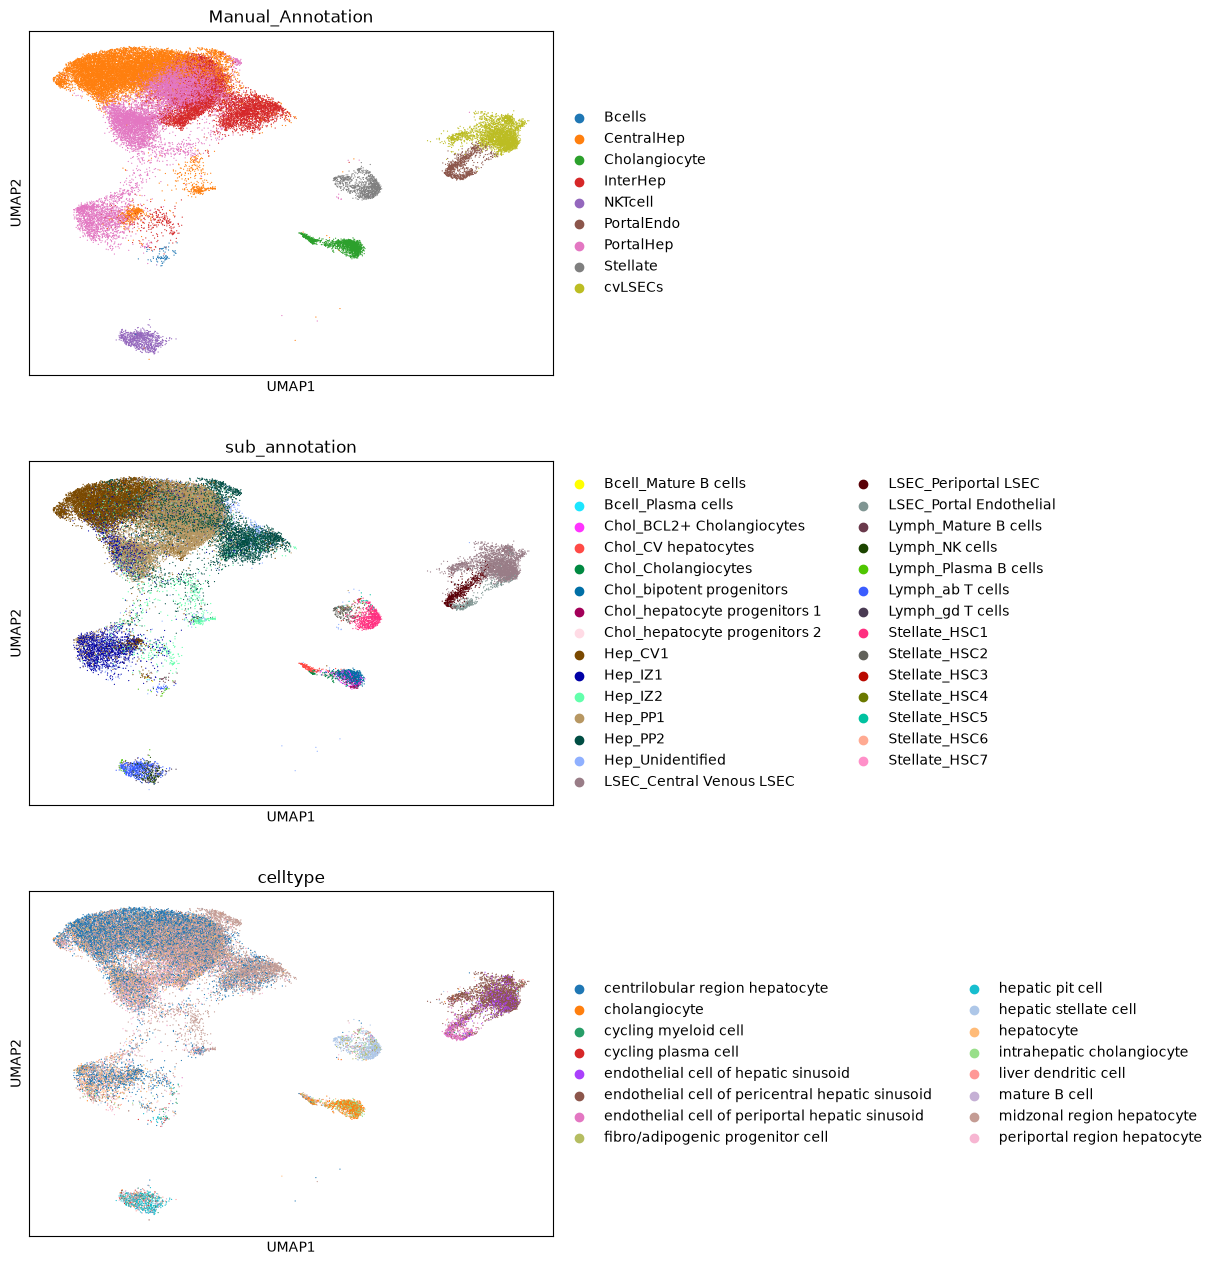

In [15]:
sc.pl.umap(adata2, color=['Manual_Annotation','sub_annotation','celltype'], ncols=1)

## 2. Major liver cell types are recovered

Modal prediction for each true cell type — the non-hepatocyte lineages map cleanly; the
three hepatocyte zones are the fine call we examine next.

In [16]:
obs = adata.obs.assign(true=adata.obs['cell_type'].astype(str),
                       pred=adata.obs['celltype'].astype(str))
modal = (obs.groupby('true')['pred']
            .agg(lambda s: s.value_counts().index[0]))
print(modal.to_string())

true
Bcells                                           hepatic pit cell
CentralHep                        centrilobular region hepatocyte
Cholangiocyte                                       cholangiocyte
InterHep                               midzonal region hepatocyte
NKTcell                                          hepatic pit cell
PortalEndo        endothelial cell of periportal hepatic sinusoid
PortalHep                              midzonal region hepatocyte
Stellate                                    hepatic stellate cell
cvLSECs          endothelial cell of pericentral hepatic sinusoid


## 3. Zoom into hepatocyte zonation

Row-normalized confusion of true zone (rows) vs predicted label (columns), collapsed to
the three zones + generic `hepatocyte` + everything else.

In [17]:
# Map any liver zone naming onto an ordinal portal(0) -> mid(1) -> central(2)
# axis, so this works whether the query uses CL ontology names
# ('periportal region hepatocyte') or short lab names (PortalHep / InterHep /
# CentralHep). Add synonyms here for your own dataset if needed.
def zone_of(label):
    s = str(label).lower()
    if 'portal' in s:                                  return 0   # peri/portal
    if 'mid' in s or 'inter' in s:                     return 1   # midzonal
    if 'central' in s or 'centri' in s or 'cent' in s: return 2   # peri/centri-central
    return None
ZLABEL = {0: 'periportal', 1: 'midzonal', 2: 'centrilobular'}

sub = obs.copy()
sub['tz'] = sub['true'].map(zone_of)          # ground-truth zone (ordinal)
sub['pz'] = sub['pred'].map(zone_of)          # predicted zone (NaN if non-zone label)
sub = sub[sub['tz'].notna()].copy()           # keep cells whose ground truth IS a zone

if len(sub) == 0:
    print("No zone-labeled hepatocytes found in the query ground truth "
          "(obs['cell_type']); skipping zonation scoring for this dataset.")
else:
    print(f"{len(sub):,} zone-labeled hepatocytes in the ground truth")
    tab = (pd.crosstab(sub['tz'].map(ZLABEL),
                       sub['pz'].map(ZLABEL).fillna('non-zone label'),
                       normalize='index')
             .reindex(index=['periportal', 'midzonal', 'centrilobular'])
             .fillna(0))
    print(tab.round(2).to_string())


33,633 zone-labeled hepatocytes in the ground truth
pz             centrilobular  midzonal  non-zone label  periportal
tz                                                                
periportal              0.27      0.33            0.17        0.23
midzonal                0.30      0.44            0.14        0.12
centrilobular           0.48      0.28            0.14        0.10


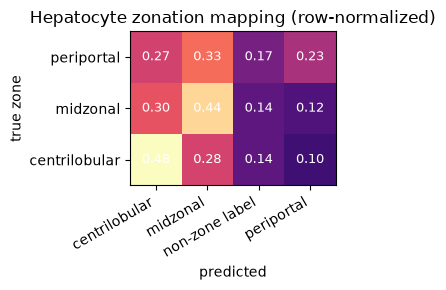

In [18]:
if len(sub) == 0:
    print("No zone ground truth; nothing to plot.")
else:
    cols = list(tab.columns)
    fig, ax = plt.subplots(figsize=(6, 3))
    im = ax.imshow(tab.values, cmap='magma', vmin=0, vmax=tab.values.max())
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=30, ha='right')
    ax.set_yticks(range(len(tab.index))); ax.set_yticklabels(tab.index)
    ax.set_xlabel('predicted'); ax.set_ylabel('true zone')
    ax.set_title('Hepatocyte zonation mapping (row-normalized)')
    for i in range(tab.shape[0]):
        for j in range(tab.shape[1]):
            v = tab.values[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.5 else 'black', fontsize=9)
    plt.tight_layout(); plt.show()


## 4. Score it ordinally — zonation is a gradient

Portal→mid→central is ordered, so the honest metrics are **within-1-zone** accuracy and
the rate of **portal↔central** flips (confusing the two extremes).

In [49]:
# Ordinal concordance on the portal->central axis (safe if there was no zone GT).
if len(sub) == 0:
    print("No zone ground truth; skipping ordinal concordance.")
else:
    z = sub.dropna(subset=['pz'])
    cov = len(z) / len(sub)
    print(f'assigned a zone to {len(z)}/{len(sub)} hepatocytes ({cov:.0%})')
    if len(z):
        print(f'exact-zone        : {(z.tz == z.pz).mean():.2f}')
        print(f'within-1-zone     : {(abs(z.tz - z.pz) <= 1).mean():.2f}')
        print(f'portal<->central  : {((z.tz - z.pz).abs() == 2).mean():.2f}  (extreme mix-ups)')


assigned a zone to 28624/33633 hepatocytes (85%)
exact-zone        : 0.43
within-1-zone     : 0.82
portal<->central  : 0.18  (extreme mix-ups)


**Takeaway.** The zonation axis is recovered — most error is between *adjacent*
zones (within-1-zone ≈ 0.9) and the two extremes are rarely swapped (portal↔central ≈ 0.1)
— but exact-zone boundaries are soft. That's expected: the broad reference carries only
~40 cells per zone. For **crisp** zonation, build a *focused* 3-zone hepatocyte reference
from more cells (`examples/build_reference.py`); the dedicated zonation study in the
[actinn-jax-benchmark](https://github.com/iandriver/actinn-jax-benchmark/blob/main/docs/ZONATION.md)
repo reaches within-1-zone ≈ 0.99, including cross-dataset transfer of the gradient.

## 5. A focused liver reference: `liver_hlica_v2`

The zonation signal above is real but the broad, 798-type reference wasn't built for
this — it has ~15-40 cells per type. `liver_hlica_v2` is a dedicated liver reference
built from [HLiCA](https://doi.org/10.64898/2026.06.30.735539) (Edgar, Portman, Hu et
al. 2026): 522,730 cells, 110 donors, 7 studies, **48 expert-curated types across 7
lineages** — thousands of cells per type instead of dozens.

v2 fixes two gaps found by checking the paper's own stated edge cases against an
earlier v1 build (see
[HLICA_EDGE_CASES.md](https://github.com/iandriver/actinn-jax-benchmark/blob/main/docs/HLICA_EDGE_CASES.md)):
v1 used HLiCA's coarser, standardized labels for 5 of 6 lineages, which silently
collapsed the paper's own headline novel-cell-type findings (NRXN1+ stromal cells,
MAMLD1+ trans monocytes, TREM2+ macrophages) into generic parent labels; and
plasmacytoid dendritic cells were entirely absent, since HLiCA structurally excludes
them from both the myeloid and lymphocyte lineage files. v2 uses the richer
per-lineage labels uniformly and adds pDCs back in — at **no cost** to the core
accuracy metrics (confirmed on the same held-out split, below).

**Note on this demo:** the liver query used above (`liver_zonation_query.h5ad`) turns
out to be drawn from HLiCA's own `Andrews_2022` component study — so it's *inside*
`liver_hlica_v2`'s training data and can't fairly measure its accuracy (the cell below
is a usage illustration only). The rigorous number comes from a proper **cross-study**
held-out test — trained on HLiCA's other 6 studies, evaluated only on the withheld
`Andrews_2022` cells never seen in training:

| model | exact-CL | ontology-concordant |
|---|---|---|
| broad_human_v1 (798 types) | 0.229 | 0.577 |
| liver_hlica_v1 (38 types, cross-study held-out) | 0.728 | 0.858 |
| **liver_hlica_v2** (48 types, cross-study held-out) | **0.724** | **0.859** |

| zonation | cells | exact-zone | portal↔central flip |
|---|---|---|---|
| hepatocyte (v2) | 27,740 | 0.789 | 0.178 |
| endothelial (v2) | 5,075 | 0.708 | 0.267 |

Recovering the lost cell types (NRXN1+ stromal cells, pDCs, and 8 other substates) cost
essentially nothing on the core metrics — the small differences above are noise, not
signal. One honest limitation, not glossed over: pDC held-out recall was 0/4 — a real
but too-small-to-conclude-anything sample (only 4 pDC cells fell in the held-out
study). A 3x jump from the broad reference regardless — the concrete payoff of the
`refine_to_query` vs. `build_reference.py` distinction in the main README: masking the
broad reference is safe but doesn't fix accuracy; retraining does.

In [50]:
liver_model = aj.bundled_reference('liver_hlica_v2')
print(f'{len(liver_model.classes)} types across '
      f'{len(set(liver_model.type_to_group.values()))} lineages')

t = time.perf_counter()
liver_out = aj.annotate(adata.copy(), liver_model)
print(f'annotated {liver_out.n_obs:,} cells in {time.perf_counter()-t:.1f}s '
      '(usage illustration -- see numbers above for the real held-out accuracy)')
liver_out.obs[['celltype', 'celltype_coarse']].head()

48 types across 7 lineages
annotated 40,171 cells in 3.1s (usage illustration -- see numbers above for the real held-out accuracy)


,celltype,celltype_coarse
C58_RESEQ_AAACGGGCAAAGCAAT-0,Periportal Hepatocyte,hepatocyte
C58_RESEQ_AAAGATGGTAGAAAGG-0,CD8 T Cell,lymphocyte
C58_RESEQ_AAAGCAAAGATGTGTA-0,CD8 T Cell,lymphocyte
C58_RESEQ_AAAGTAGGTGCTGTAT-0,CD8 T Cell,lymphocyte
C58_RESEQ_AAAGTAGGTTTGGGCC-0,CD8 T Cell,lymphocyte


In [51]:
Counter(liver_out.obs['celltype'])

Counter({'Periportal Hepatocyte': 16360,
         'Pericentral Hepatocyte': 7870,
         'Ribosomal+ Hepatocyte': 6778,
         'Periportal LSEC': 1704,
         'Central Venous LSEC': 1569,
         'ApoLipo': 1349,
         'Hepatic Stellate Cell': 762,
         'CD8 T Cell': 595,
         'SERPINE1+ Hepatocyte': 571,
         'UGT+ Hepatocyte': 500,
         'Vascular Endothelial Cell': 297,
         'Hepatic Artery': 282,
         'Portal Fibroblast': 282,
         'lymphocyte': 271,
         'Portal Vein': 167,
         'CUX2+ Hepatic Stellate Cell': 166,
         'Dim NK Cell': 153,
         'Keratin': 108,
         'Bright NK Cell': 78,
         'B Cell': 52,
         'LAMC2+ Cholangiocyte': 44,
         'MAIT T Cell': 43,
         'IgA B cells': 26,
         'IgG B cells': 24,
         'Classical Monocytes': 23,
         'Helper T Cell': 23,
         'Mucus Secreting': 16,
         'Mito+ Hepatocyte': 14,
         'NRXN1+ Stromal Cell': 12,
         'Vascular Smooth Muscle C

In [59]:
adata3 = liver_out[liver_out.obs['celltype'].isin([a[0] for a in Counter(liver_out.obs['celltype']).most_common() if a[1]>10])].copy()

In [60]:
adata3.uns['celltype_colors']={}

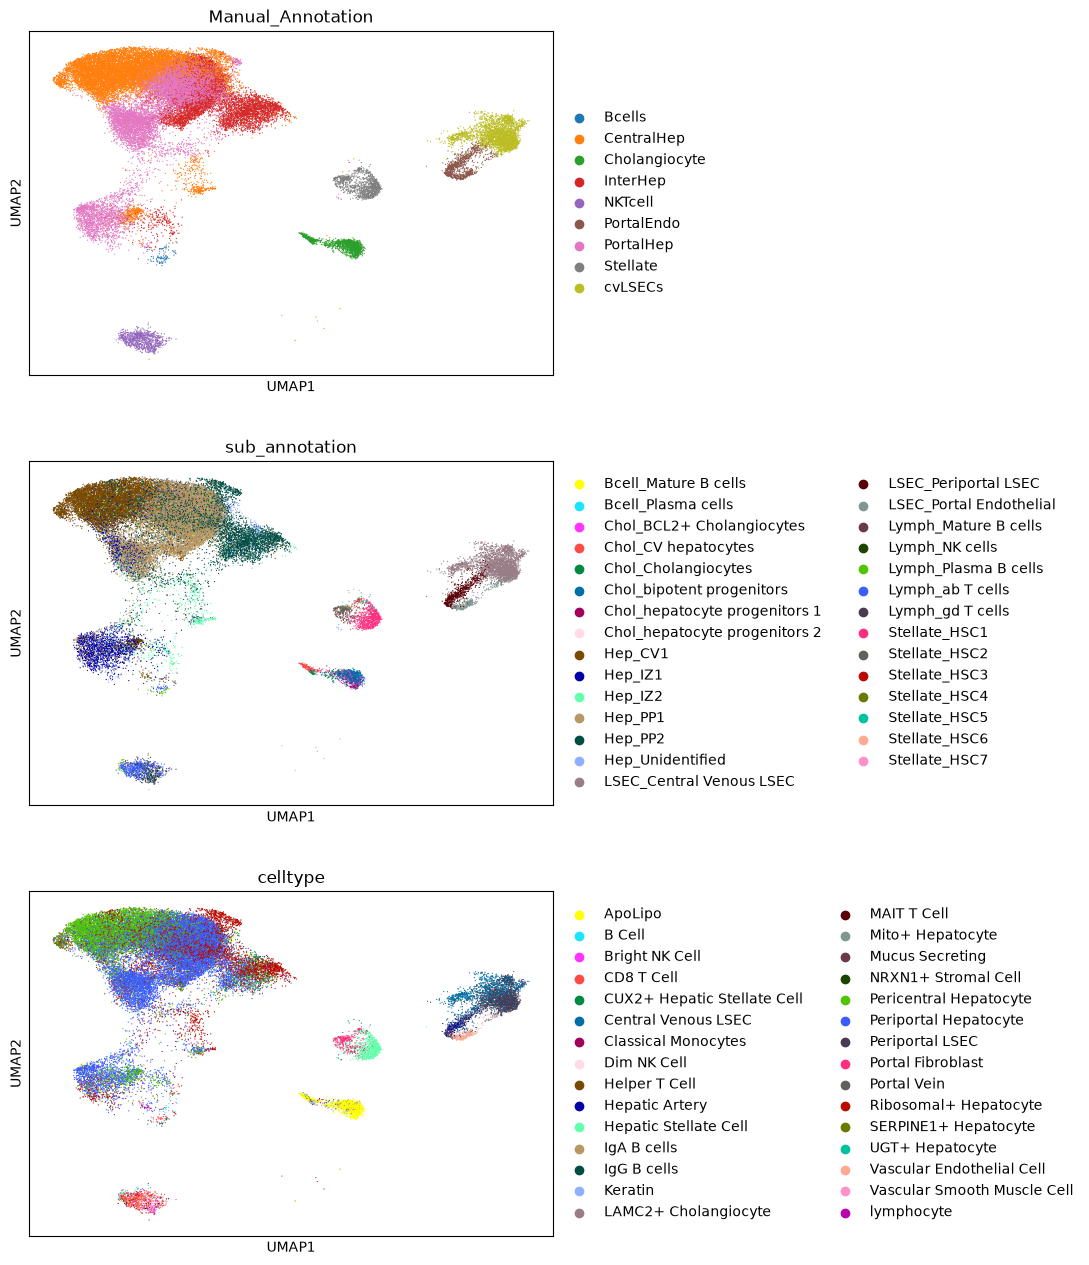

In [61]:
sc.pl.umap(adata3, color=['Manual_Annotation','sub_annotation','celltype'], ncols=1)

In [76]:
model = aj.bundled_reference("liver_hlica_v2")
adata4 = aj.annotate(adata.copy(), model)

In [77]:
Counter(adata4.obs['celltype'])

Counter({'Periportal Hepatocyte': 16360,
         'Pericentral Hepatocyte': 7870,
         'Ribosomal+ Hepatocyte': 6778,
         'Periportal LSEC': 1704,
         'Central Venous LSEC': 1569,
         'ApoLipo': 1349,
         'Hepatic Stellate Cell': 762,
         'CD8 T Cell': 595,
         'SERPINE1+ Hepatocyte': 571,
         'UGT+ Hepatocyte': 500,
         'Vascular Endothelial Cell': 297,
         'Hepatic Artery': 282,
         'Portal Fibroblast': 282,
         'lymphocyte': 271,
         'Portal Vein': 167,
         'CUX2+ Hepatic Stellate Cell': 166,
         'Dim NK Cell': 153,
         'Keratin': 108,
         'Bright NK Cell': 78,
         'B Cell': 52,
         'LAMC2+ Cholangiocyte': 44,
         'MAIT T Cell': 43,
         'IgA B cells': 26,
         'IgG B cells': 24,
         'Classical Monocytes': 23,
         'Helper T Cell': 23,
         'Mucus Secreting': 16,
         'Mito+ Hepatocyte': 14,
         'NRXN1+ Stromal Cell': 12,
         'Vascular Smooth Muscle C

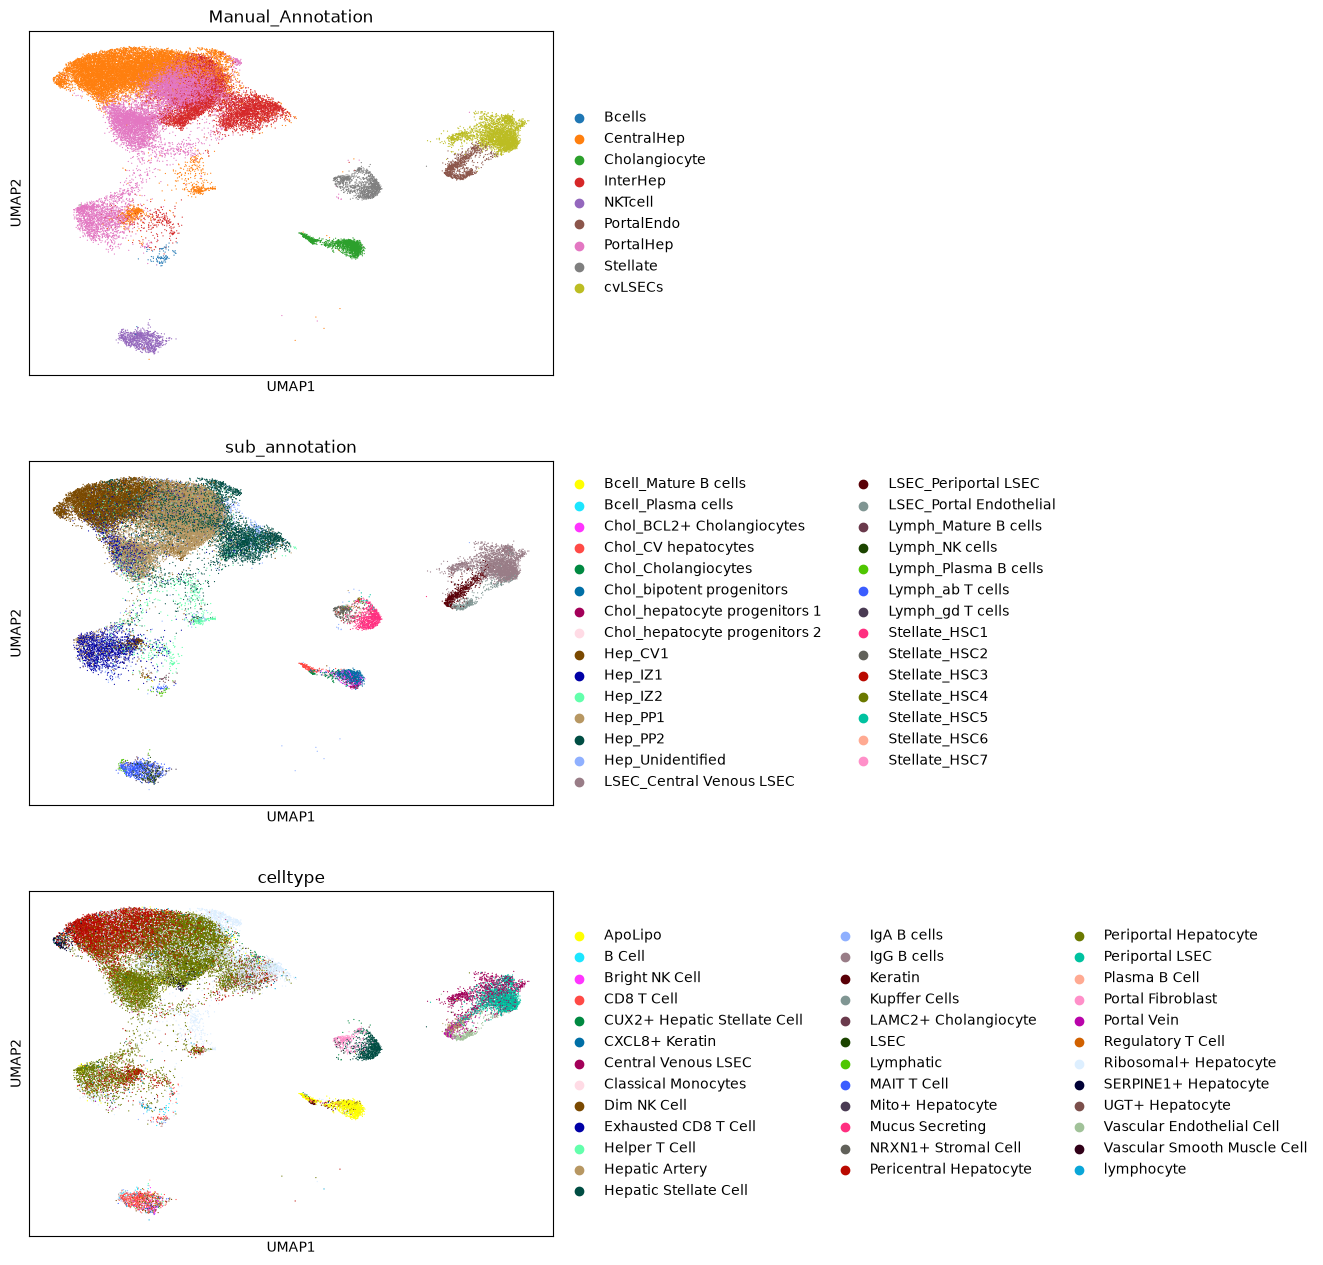

In [78]:
sc.pl.umap(adata4, color=['Manual_Annotation','sub_annotation','celltype'], ncols=1)

### Attribution

`liver_hlica_v2` is built from data made available by Edgar, R.D., Portman, J.R., Hu,
H. et al. **HLiCA: An integrated cell atlas of the healthy human liver.** bioRxiv
(2026). https://doi.org/10.64898/2026.06.30.735539 (CC-BY 4.0). Please cite the
original paper if you use this reference.

## Tissue-aware refine

A sample is (mostly) one tissue, and a liver sample should not be labeled with lung/heart/gut cell types. `refine_to_tissue` prunes the broad reference to the cell types the census records in a given tissue, while keeping pan-tissue types (immune, endothelial, stromal) everywhere. The tissue map ships baked into the model.

In [ ]:
broad = aj.bundled_reference('broad_human_v1')
base  = aj.annotate(adata.copy(), broad)
tiss  = aj.refine_to_tissue(broad, tissue='liver').predict(adata.copy())
print(f"broad model      : {base.obs['celltype'].nunique()} distinct labels")
print(f"tissue='liver'    : {tiss.obs['celltype'].nunique()} distinct labels")
removed = sorted(set(base.obs['celltype']) - set(tiss.obs['celltype']))
print(f"cross-tissue labels pruned ({len(removed)}): {removed[:12]}")